In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

1a

In [ ]:
# Parameters
Vfs = 1.0  # Full-scale voltage
bits = 2.5
num_comparators = 6
num_levels = num_comparators + 1

# Reference levels (equally spaced)
v_ref = np.linspace(0, Vfs, num_levels + 1)[1:-1]

print("Number of Comparators:", num_levels)
print("Reference Levels:", v_ref)

Number of Comparators: 7
Reference Levels: [0.14285714 0.28571429 0.42857143 0.57142857 0.71428571 0.85714286]


1b

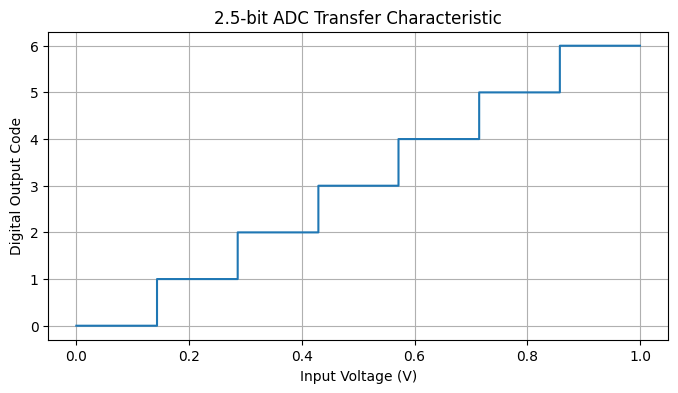

In [ ]:
def get_adc_output(v_in, offsets=0):
    # Apply input to comparators
    thermometer_code = (v_in[:, None] > (v_ref + offsets)).astype(int)
    # Digital output is the sum of bits (thermometer to decimal)
    digital_out = np.sum(thermometer_code, axis=1)
    return digital_out

# Sweep input voltage
v_in_sweep = np.linspace(0, Vfs, 1000)
digital_out = get_adc_output(v_in_sweep)

plt.figure(figsize=(8, 4))
plt.step(v_in_sweep, digital_out, where='post')
plt.title("2.5-bit ADC Transfer Characteristic")
plt.xlabel("Input Voltage (V)")
plt.ylabel("Digital Output Code")
plt.grid(True)
plt.show()

1c

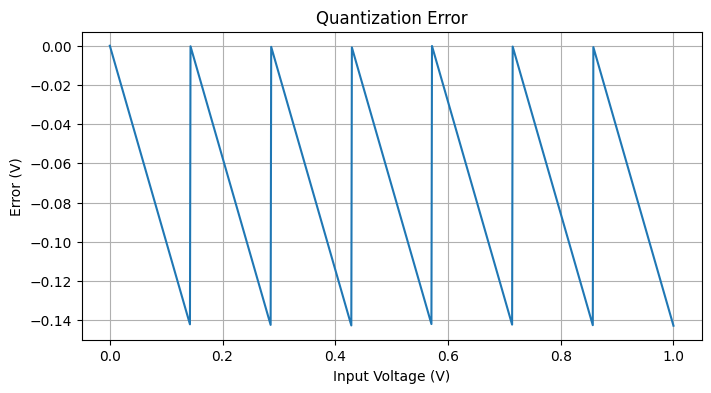

Max Error: 0.0000 V
Min Error: -0.1429 V


In [ ]:
# Reconstruct analog signal: digital_code * (VFS / num_levels)
v_reconstructed = digital_out * (Vfs / num_levels)
quant_error = v_reconstructed - v_in_sweep

plt.figure(figsize=(8, 4))
plt.plot(v_in_sweep, quant_error)
plt.title("Quantization Error")
plt.xlabel("Input Voltage (V)")
plt.ylabel("Error (V)")
plt.grid(True)
plt.show()

print(f"Max Error: {np.max(quant_error):.4f} V")
print(f"Min Error: {np.min(quant_error):.4f} V")

1d

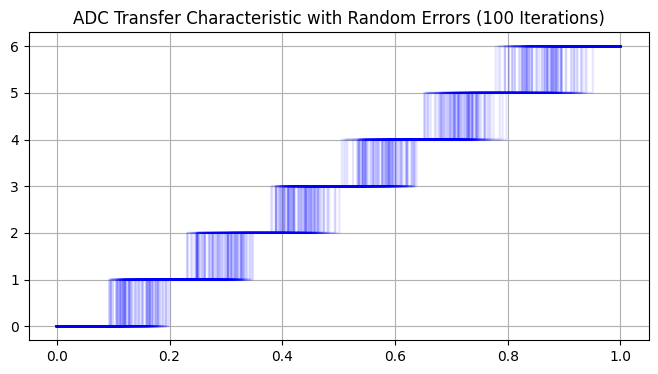

In [ ]:
def get_adc_non_linear(v_in, gain_err, offset_err, n2, n3):
    # Apply non-linearities to the input signal
    v_distorted = gain_err * v_in + n2 * v_in**2 + n3 * v_in**3
    return get_adc_output(v_distorted, offsets=offset_err)

plt.figure(figsize=(8, 4))
for _ in range(100):
    g = np.random.uniform(0.95, 1.05)
    o = np.random.uniform(-0.05, 0.05, num_comparators)
    n2 = np.random.uniform(-0.02, 0.02)
    n3 = np.random.uniform(-0.02, 0.02)

    out = get_adc_non_linear(v_in_sweep, g, o, n2, n3)
    plt.step(v_in_sweep, out, alpha=0.1, color='blue', where='post')

plt.title("ADC Transfer Characteristic with Random Errors (100 Iterations)")
plt.grid()
plt.show()

1e

In [ ]:
# Use only offset errors
offsets = np.random.uniform(-0.05, 0.05, num_comparators)
v_in_dense = np.linspace(0, Vfs, 10000)
codes = get_adc_output(v_in_dense, offsets=offsets)

# Find transitions
transitions = v_in_dense[np.where(np.diff(codes) > 0)]
step_widths = np.diff(np.concatenate(([0], transitions, [Vfs])))

ideal_width = Vfs / num_levels
dnl = (step_widths - ideal_width) / ideal_width
inl = np.cumsum(dnl)

print(f"DNL: {dnl}")
print(f"INL: {inl}")

DNL: [ 0.3420342  -0.33563356 -0.17881788  0.26082608  0.13691369 -0.13191319
 -0.09340934]
INL: [ 3.42034203e-01  6.40064006e-03 -1.72417242e-01  8.84088409e-02
  2.25322532e-01  9.34093409e-02  3.88578059e-16]


1f

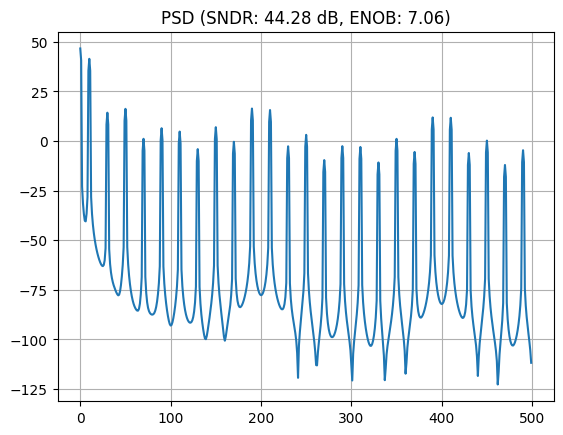

In [ ]:
fs = 1000  # Sampling frequency
f_sig = 10  # Signal frequency
t = np.arange(fs) / fs
v_sine = 0.5 * np.sin(2 * np.pi * f_sig * t) + 0.5 # Normalized 0 to 1

# Get quantized output
v_quant = get_adc_output(v_sine) / num_levels

# FFT and PSD
window = np.hanning(len(v_quant))
v_fft = fft(v_quant * window)
psd = 20 * np.log10(np.abs(v_fft[:fs // 2]))

# SNDR calculation (simplified)
signal_power = np.max(psd)
noise_power = 10 * np.log10(np.sum(10**(psd / 10))) - signal_power
sndr = signal_power - noise_power
enob = (sndr - 1.76) / 6.02

plt.plot(psd)
plt.title(f"PSD (SNDR: {sndr:.2f} dB, ENOB: {enob:.2f})")
plt.grid()
plt.show()

1g

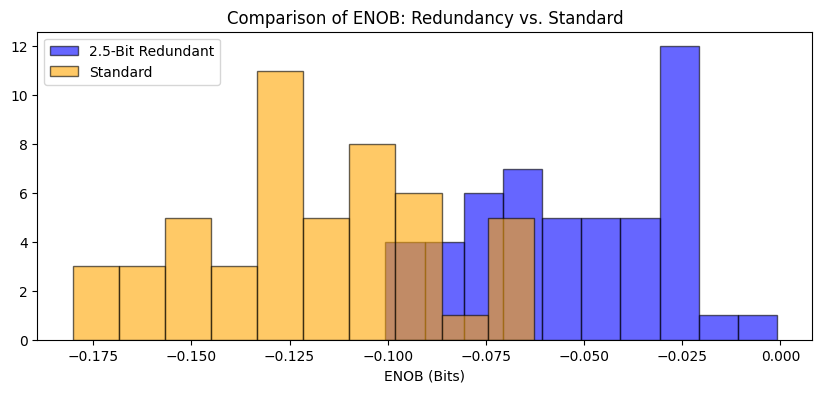

'\nRedundancy Performance: The histograms will show that the Redundant architecture has a higher and more consistent ENOB.\nDNL/INL Mechanism: Redundancy improves DNL/INL because the extra comparator levels (6 vs 3) act as a "buffer." If one comparator has a large offset error, the extra levels prevent "missing codes" (large gaps in the transfer curve).\nError Correction: In the redundant version, the search ranges overlap. This allows the ADC to tolerate hardware imperfections as long as they stay within the redundancy range (usually \nLSB).\n'

In [ ]:
def run_monte_carlo(num_comps, label):
    enob_results = []
    sndr_results = []
    num_levels = num_comps + 1
    v_ref = np.linspace(0, 1.0, num_levels + 1)[1:-1]

    # Setup input signal (10 Hz sine)
    fs = 1000
    t = np.arange(fs) / fs
    v_sine = 0.5 * np.sin(2 * np.pi * 10 * t) + 0.5

    for i in range(50):
        np.random.seed(i) # Hint requirement

        # Random variables (offset, gain, 2nd/3rd order)
        g = np.random.uniform(0.98, 1.02)
        o = np.random.uniform(-0.05, 0.05, num_comps)
        n2 = np.random.uniform(-0.01, 0.01)
        n3 = np.random.uniform(-0.01, 0.01)

        # Apply non-linearities and quantize
        v_dist = g * v_sine + n2 * v_sine**2 + n3 * v_sine**3
        therm = (v_dist[:, None] > (v_ref + o)).astype(int)
        v_out = np.sum(therm, axis=1) / num_levels

        # Measure SNDR/ENOB (updated FFT inside loop)
        v_fft = np.abs(fft(v_out * np.hanning(fs)))[:fs//2]
        sig_pwr = np.max(v_fft)**2
        noise_pwr = np.sum(v_fft**2) - sig_pwr

        sndr = 10 * np.log10(sig_pwr / max(noise_pwr, 1e-12))
        enob = (sndr - 1.76) / 6.02

        enob_results.append(enob)
        sndr_results.append(sndr)

    return sndr_results, enob_results

# Execute for BOTH architectures
# 2.5-bit redundant (6 comparators) vs. standard (3 comparators for 2-bit)
sndr_red, enob_red = run_monte_carlo(6, "Redundant")
sndr_std, enob_std = run_monte_carlo(3, "Standard")

# Generate and compare histograms
plt.figure(figsize=(10, 4))
plt.hist(enob_red, alpha=0.6, label='2.5-Bit Redundant', color='blue', edgecolor='black')
plt.hist(enob_std, alpha=0.6, label='Standard', color='orange', edgecolor='black')
plt.title("Comparison of ENOB: Redundancy vs. Standard")
plt.xlabel("ENOB (Bits)")
plt.legend()
plt.show()

2a

In [ ]:
# Constants
Vfs = 1.0
Vref = Vfs
gain = 4  # Residue gain for 2.5-bit stage

# Ideal decision levels from sub-ADC (Section 1)
v_ref_levels = np.linspace(0, Vfs, 7 + 1)[1:-1]

def mdac_stage(v_in):
    # Determine the digital code (0 to 6)
    # This mimics the sub-ADC logic
    code = np.sum(v_in[:, None] > v_ref_levels, axis=1)

    # MDAC Residue Equation: Vout = Gain * (Vin - Vdac)
    # The DAC voltage (Vdac) typically shifts the residue back to center
    v_dac = code * (Vfs / 4) # Standard MDAC step sizing
    v_residue = gain * (v_in - v_dac)

    return v_residue, code

# Sweep input for testing
v_in_sweep = np.linspace(0, Vfs, 1000)
residue, codes = mdac_stage(v_in_sweep)

2b

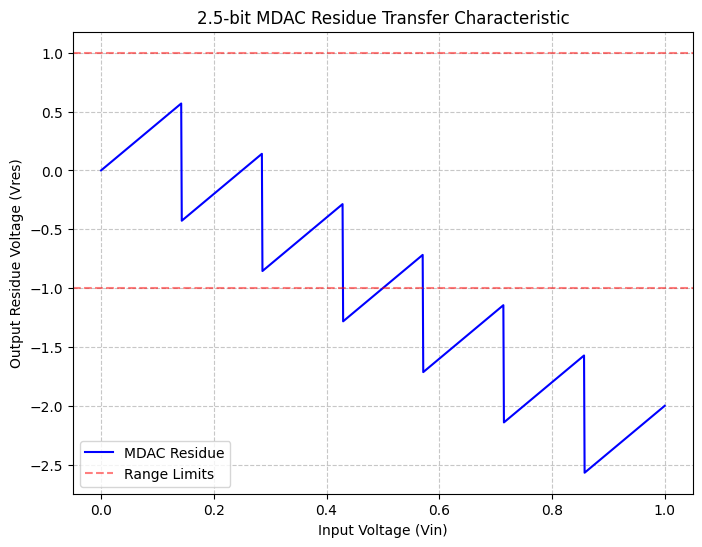

Mean Gain (Slope): 4.00
Max Deviation from Ideal Gain: 0.0000


In [ ]:
# Plot the residue plot (transfer Characteristic)
plt.figure(figsize=(8, 6))
plt.plot(v_in_sweep, residue, label='MDAC Residue', color='blue')
plt.axhline(y=Vfs, color='r', linestyle='--', alpha=0.5, label='Range Limits')
plt.axhline(y=-Vfs, color='r', linestyle='--', alpha=0.5)

plt.title("2.5-bit MDAC Residue Transfer Characteristic")
plt.xlabel("Input Voltage (Vin)")
plt.ylabel("Output Residue Voltage (Vres)")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Linearity verification: check slope (derivative) of the segments
slopes = np.diff(residue) / np.diff(v_in_sweep)
# Filter out the vertical reset lines of the sawtooth
valid_slopes = slopes[np.abs(slopes) < 10]

print(f"Mean Gain (Slope): {np.mean(valid_slopes):.2f}")
print(f"Max Deviation from Ideal Gain: {np.max(np.abs(valid_slopes - 4)):.4f}")

3a

In [ ]:
# Constants
Vfs = 1.0
G = 4

# Behavioral model
def ideal_residue_amp(v_in):
    return G * v_in

3b

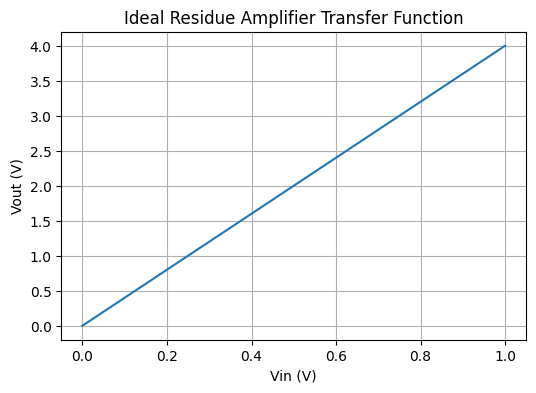

In [ ]:
# Sweep and plot
v_in_sweep = np.linspace(0, Vfs, 1000)
v_out_ideal = ideal_residue_amp(v_in_sweep)

plt.figure(figsize=(6, 4))
plt.plot(v_in_sweep, v_out_ideal, label='Ideal (G = 4)')
plt.title("Ideal Residue Amplifier Transfer Function")
plt.xlabel("Vin (V)")
plt.ylabel("Vout (V)")
plt.grid(True)
plt.show()

3c

In [ ]:
fs = 1000
t = np.arange(fs) / fs
v_sine = 0.45 * np.sin(2 * np.pi * 10 * t) # Amplitude near VFS / 2 for G = 4 range

def analyze_spectral(signal, label):
    window = np.hanning(len(signal))
    v_fft = np.abs(fft(signal * window))[:fs // 2]
    psd = 20 * np.log10(v_fft / np.max(v_fft) + 1e-12)

    # Simple SNDR/ENOB
    sig_pwr = np.max(v_fft) ** 2
    noise_pwr = np.sum(v_fft ** 2) - sig_pwr
    sndr = 10 * np.log10(sig_pwr / noise_pwr)
    enob = (sndr - 1.76) / 6.02
    return psd, sndr, enob

psd_ideal, sndr_id, enob_id = analyze_spectral(ideal_residue_amp(v_sine), "Ideal")
print(f"Ideal SNDR: {sndr_id:.2f} dB")
print(f"Ideal ENOB: {enob_id:.2f}")

Ideal SNDR: 3.00 dB
Ideal ENOB: 0.21


3d

In [ ]:
def nonlinear_amp(v_in, eps, v_off, a2, a3):
    return (1 + eps) * G * v_in + v_off + a2 * v_in ** 2 + a3 * v_in ** 3

3e

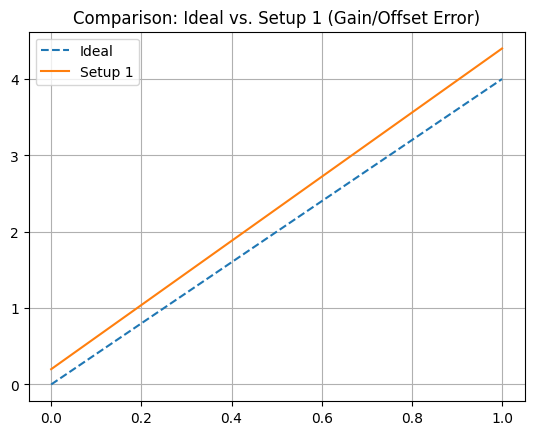

In [ ]:
# Setup 1 Comparison
v_out_s1 = nonlinear_amp(v_in_sweep, 0.05, 0.2 * Vfs, 0, 0)

plt.plot(v_in_sweep, v_out_ideal, '--', label='Ideal')
plt.plot(v_in_sweep, v_out_s1, label='Setup 1')
plt.legend()
plt.title("Comparison: Ideal vs. Setup 1 (Gain/Offset Error)")
plt.grid()
plt.show()

3f

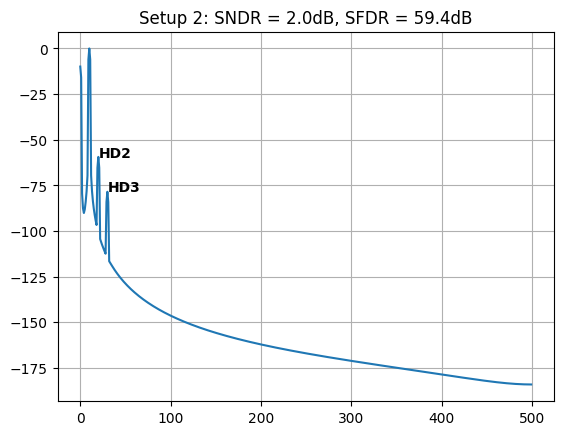

In [ ]:
def plot_setup_performance(eps, voff, a2, a3, title):
    v_out = nonlinear_amp(v_sine, eps, voff, a2, a3)
    psd, sndr, enob = analyze_spectral(v_out, title)

    # SFDR calculation: find max harmonic relative to signal
    # Indices for 10 Hz, 20 Hz, 30 Hz
    sig_bin, h2_bin, h3_bin = 10, 20, 30
    sfdr = psd[sig_bin] - max(psd[h2_bin], psd[h3_bin])

    plt.plot(psd)
    plt.annotate('HD2', xy=(h2_bin, psd[h2_bin]), weight='bold')
    plt.annotate('HD3', xy=(h3_bin, psd[h3_bin]), weight='bold')
    plt.title(f"{title}: SNDR = {sndr:.1f}dB, SFDR = {sfdr:.1f}dB")
    plt.grid()
    plt.show()

plot_setup_performance(0.05, 0.3, 0.02, 0.01, "Setup 2")

3g

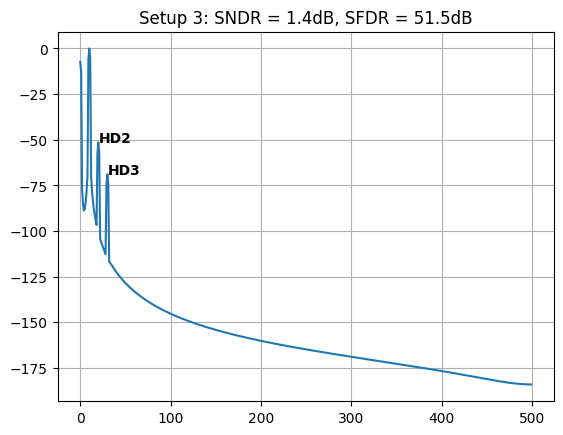

In [ ]:
plot_setup_performance(0.05, 0.4, 0.05, 0.03, "Setup 3")

3h

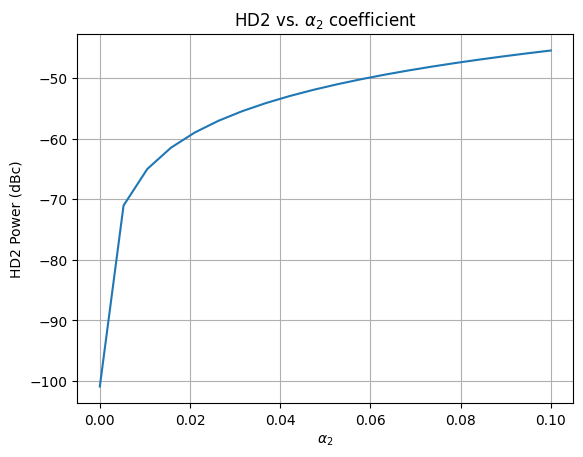

In [ ]:
# Sweep a2
a2_sweep = np.linspace(0, 0.1, 20)
hd2_vals = []
for a in a2_sweep:
    v_out = nonlinear_amp(v_sine, 0.05, 0.2, a, 0)
    p = analyze_spectral(v_out, "")[0]
    hd2_vals.append(p[20]) # HD2 power at 20 Hz bin

plt.plot(a2_sweep, hd2_vals)
plt.title("HD2 vs. $\\alpha_2$ coefficient")
plt.xlabel("$\\alpha_2$")
plt.ylabel("HD2 Power (dBc)")
plt.grid()
plt.show()

3i

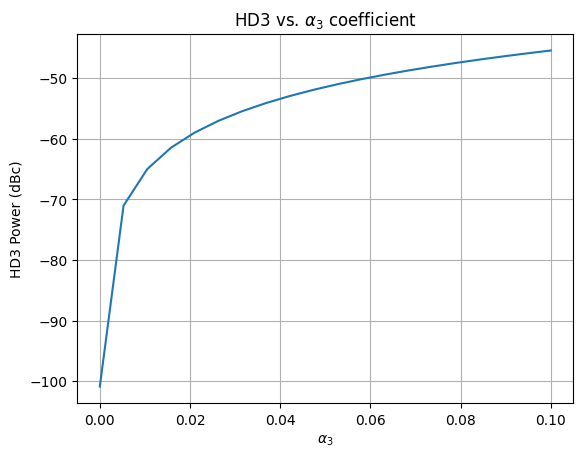

In [ ]:
# Sweep a3
a3_sweep = np.linspace(0, 0.1, 20)
hd3_vals = []
for a in a3_sweep:
    v_out = nonlinear_amp(v_sine, 0.05, 0.3, a, 0)
    p = analyze_spectral(v_out, "")[0]
    hd3_vals.append(p[20]) # HD3 power at 20 Hz bin

plt.plot(a3_sweep, hd3_vals)
plt.title("HD3 vs. $\\alpha_3$ coefficient")
plt.xlabel("$\\alpha_3$")
plt.ylabel("HD3 Power (dBc)")
plt.grid()
plt.show()

4a

In [ ]:
# Parameters
VFS = 1.0

# SINGLE 2.5-BIT MDAC STAGE
def get_mdac_output(v_in, v_ref=1.0, sub_off=0.0, gain_err=0.0, ra_off=0.0, a2=0.0, a3=0.0):
    # 2.5-bit thresholds
    thresholds = np.array([-5 / 8, -3 / 8, -1 / 8, 1 / 8, 3 / 8, 5 / 8]) * v_ref

    # Comparator offset
    thresholds += sub_off

    # Sub-ADC decision
    d = np.sum(v_in > thresholds) - 3

    # DAC output
    v_dac = d * (v_ref / 4)

    # Ideal residue
    v_res_ideal = 2 * (v_in - v_dac)

    # Residue amplifier nonidealities
    v_res = (1 + gain_err) * v_res_ideal
    v_res += ra_off
    v_res += a2 * (v_res_ideal ** 2)
    v_res += a3 * (v_res_ideal ** 3)

    return d, v_res

# Full pipelined ADC
def pipelined_adc(v_in, params_list, redundancy=True):
    residue = v_in
    digits = []

    # Pipeline stages
    for params in params_list:
        d, residue = get_mdac_output(residue, **params)
        digits.append(d)

    # Final flash stage
    d_last = np.sum(residue > np.array([-0.25, 0.25])) - 1
    digits.append(d_last)

    # Digital output
    output = (digits[0] * 16 + digits[1] * 4 + digits[2])
    return output

4b

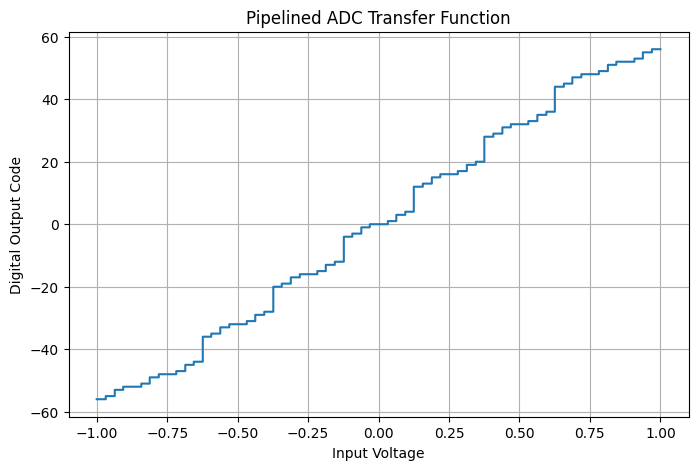

In [ ]:
# Transfer function
vin_ramp = np.linspace(-VFS, VFS, 1000)
params_ideal = [{'sub_off': 0, 'gain_err': 0, 'ra_off': 0, 'a2': 0, 'a3': 0} for _ in range(3)]
vout_ramp = [pipelined_adc(v, params_ideal) for v in vin_ramp]

plt.figure(figsize=(8, 5))
plt.step(vin_ramp, vout_ramp, where='post')
plt.title("Pipelined ADC Transfer Function")
plt.xlabel("Input Voltage")
plt.ylabel("Digital Output Code")
plt.grid()
plt.show()

4c

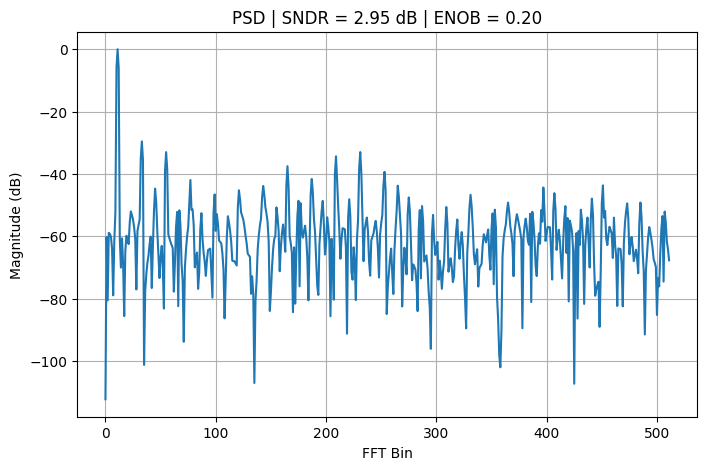

SNDR = 2.95 dB
ENOB = 0.20 bits


In [ ]:
# FFT analysis
fs = 1024
fin = 11
n = np.arange(fs)
v_in_tone = 0.9 * np.sin(2 * np.pi * fin * n / fs)

def analyze_performance(v_out):
    v_out = np.array(v_out)

    # Window
    window = np.hanning(len(v_out))
    v_win = v_out * window

    # FFT
    fft_res = np.abs(np.fft.fft(v_win))[:fs // 2]
    psd = 20 * np.log10(fft_res / np.max(fft_res) + 1e-12)

    # Signal power
    signal_bin = fin
    p_signal = fft_res[signal_bin] ** 2

    # Noise power
    p_noise = np.sum(fft_res ** 2)
    p_noise -= fft_res[0] ** 2
    p_noise -= p_signal
    sndr = 10 * np.log10(p_signal / (p_noise + 1e-12))
    enob = (sndr - 1.76) / 6.02

    return psd, sndr, enob

# Run ideal ADC
vout_tone = [pipelined_adc(v, params_ideal) for v in v_in_tone]
psd, sndr_val, enob_val = analyze_performance(vout_tone)

plt.figure(figsize=(8, 5))
plt.plot(psd)
plt.title(f"PSD | SNDR = {sndr_val:.2f} dB | ENOB = {enob_val:.2f}")
plt.xlabel("FFT Bin")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

print(f"SNDR = {sndr_val:.2f} dB")
print(f"ENOB = {enob_val:.2f} bits")

4d

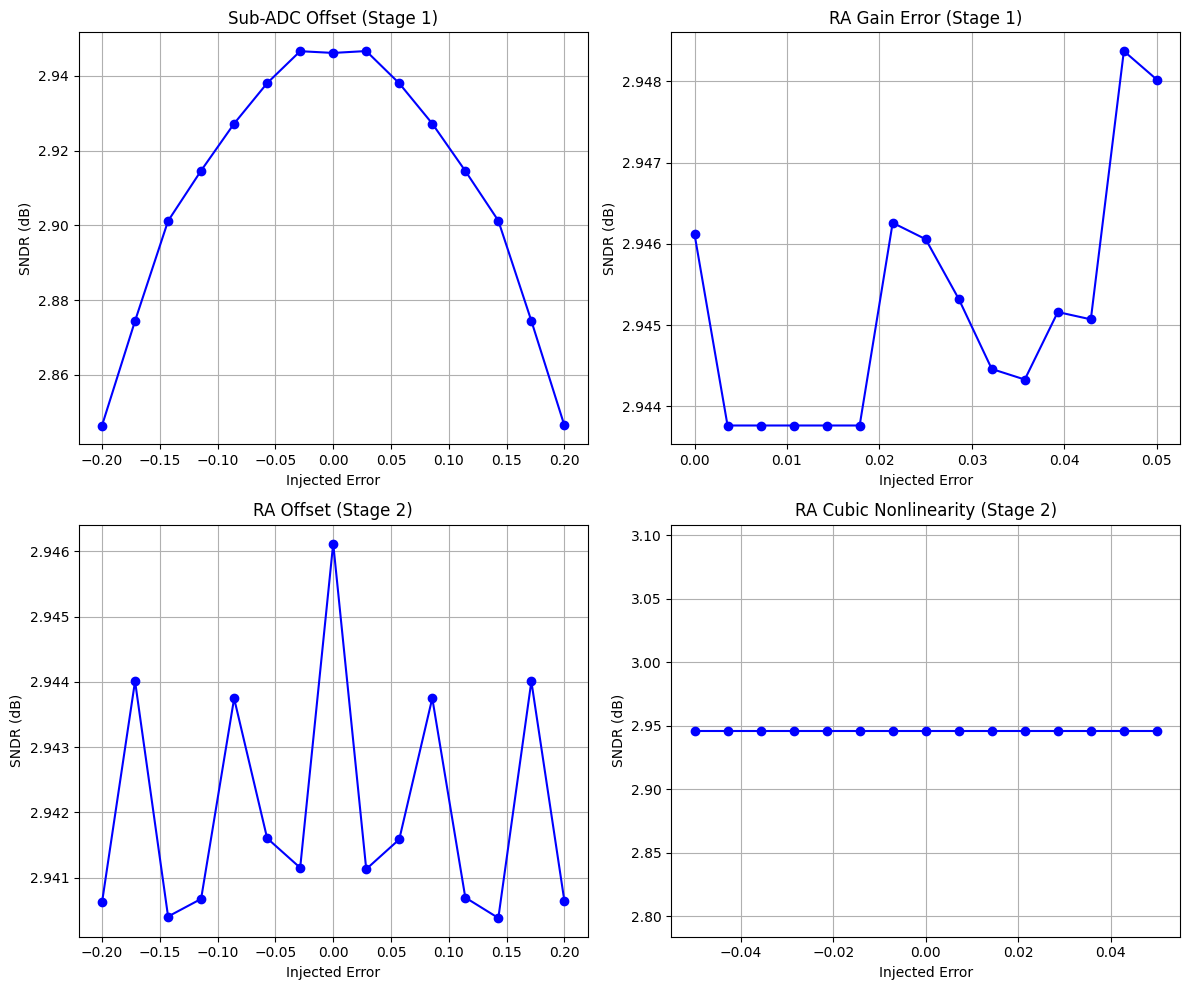

In [ ]:
# Parameter sweep function
N_POINTS = 15

def run_sweep(param_key, stage_idx, is_ra, range_vals, use_redundancy):
    sweep_values = np.linspace(range_vals[0], range_vals[1], N_POINTS)
    sndr_results = []

    for val in sweep_values:
        # Ideal stages
        stages = []
        for _ in range(3):
            stages.append({'sub_off':0, 'gain_err':0, 'ra_off':0, 'a2':0, 'a3':0})

        # Inject error
        if is_ra:
            stages[stage_idx][param_key] = val
        else:
            stages[stage_idx]['sub_off'] = val

        # Run ADC
        v_out = [pipelined_adc(v, stages, redundancy=use_redundancy) for v in v_in_tone]
        _, sndr, _ = analyze_performance(v_out)
        sndr_results.append(sndr)

    return sweep_values, sndr_results

# Sweep configurations
sweep_configs = [
    ("Sub-ADC Offset (Stage 1)", 'sub_off', 0, False, [-0.2*VFS, 0.2*VFS]),
    ("RA Gain Error (Stage 1)", 'gain_err', 0, True, [0, 0.05]),
    ("RA Offset (Stage 2)", 'ra_off', 1, True, [-0.2*VFS, 0.2*VFS]),
    ("RA Cubic Nonlinearity (Stage 2)", 'a3', 1, True, [-0.05, 0.05])
]

# Plot sweeps
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, (title, key, stg, is_ra, r) in enumerate(sweep_configs):
    x, sndr_vals = run_sweep(key, stg, is_ra, r, use_redundancy=True)

    axes[i].plot(x, sndr_vals, 'b-o')
    axes[i].set_title(title)
    axes[i].set_xlabel("Injected Error")
    axes[i].set_ylabel("SNDR (dB)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

4e

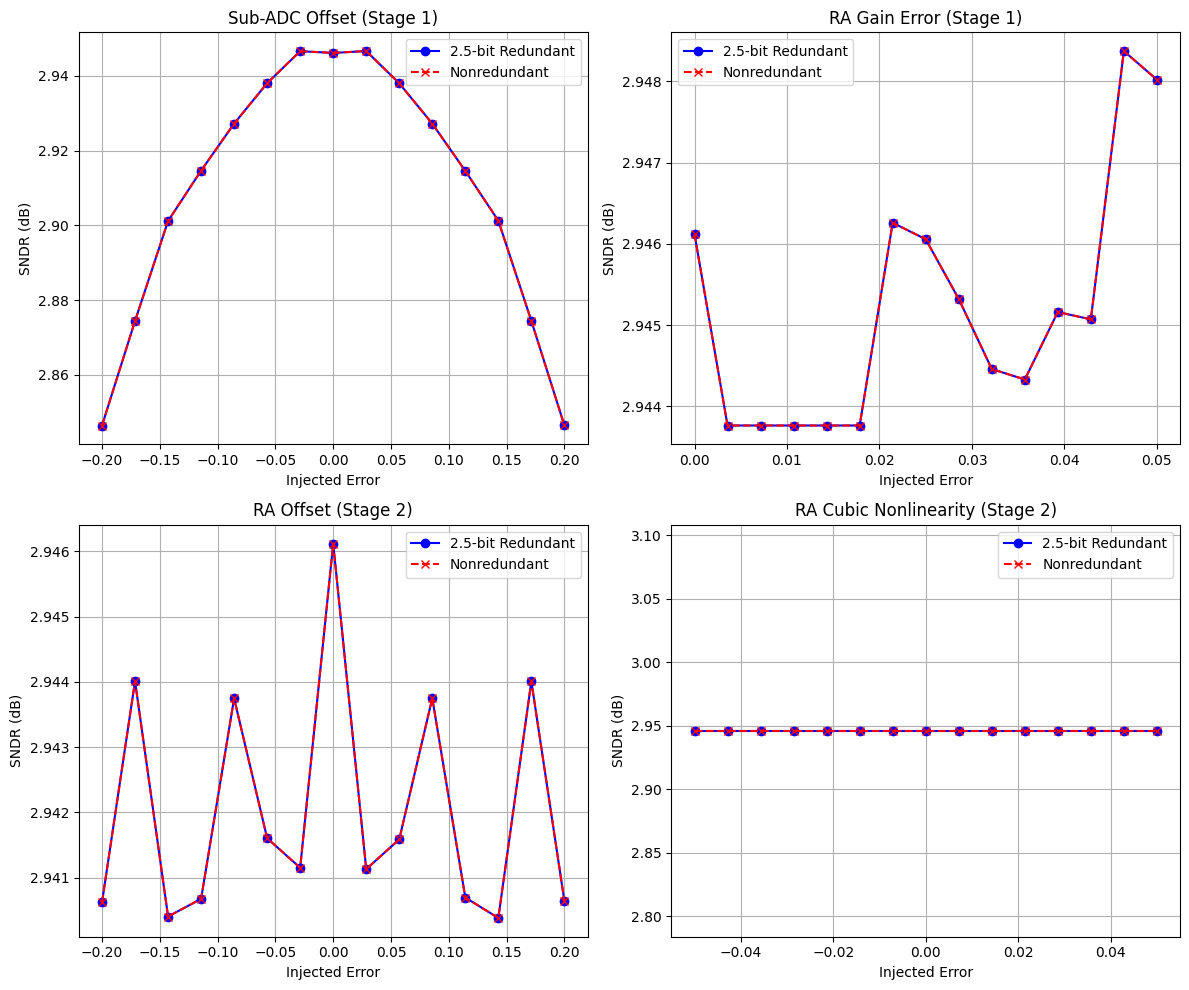

In [ ]:
# Redundant vs. nonredundant
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (title, key, stg, is_ra, r) in enumerate(sweep_configs):
    # Redundant
    x_red, sndr_red = run_sweep(key, stg, is_ra, r, use_redundancy=True)

    # Nonredundant
    x_std, sndr_std = run_sweep(key, stg, is_ra, r, use_redundancy=False)

    axes[i].plot(x_red, sndr_red, 'b-o', label='2.5-bit Redundant')
    axes[i].plot(x_std, sndr_std, 'r--x', label='Nonredundant')
    axes[i].set_title(title)
    axes[i].set_xlabel("Injected Error")
    axes[i].set_ylabel("SNDR (dB)")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

4f

In [ ]:
"""
Observations:
1. Redundancy improves tolerance to comparator offsets. Small Sub-ADC offsets produce little SNDR degradation
2. Nonredundant architectures degrade faster because there is no digital overlap correction
3. Residue amplifier gain errors affect both systems. Redundancy cannot fully correct analog gain errors
4. Third-order nonlinearity (a3) creates harmonic distortion and lowers SFDR/SNDR
5. The SNDR surfaces are non-convex because quantization creates abrupt transition boundaries

Calibration ideas:
1. Comparator offset calibration
2. Digital background calibration
3. Gain correction coefficients
4. Harmonic cancellation techniques
"""

'\nObservations:\n1. Redundancy improves tolerance to comparator offsets. Small Sub-ADC offsets produce little SNDR degradation\n2. Nonredundant architectures degrade faster because there is no digital overlap correction\n3. Residue amplifier gain errors affect both systems. Redundancy cannot fully correct analog gain errors\n4. Third-order nonlinearity (a3) creates harmonic distortion and lowers SFDR/SNDR\n5. The SNDR surfaces are non-convex because quantization creates abrupt transition boundaries\n\nCalibration ideas:\n1. Comparator offset calibration\n2. Digital background calibration\n3. Gain correction coefficients\n4. Harmonic cancellation techniques\n'